In [19]:
import torch
import torch.nn as nn
import numpy as np
from model import LSTMClassifier

In [20]:
def predict(model, df, feature_cols, window=60, device="cpu"):
    """
    df: DataFrame с уже посчитанными фичами (те же, что при обучении!)
    Возвращает предсказание для ПОСЛЕДНЕГО окна в df
    """
    model.eval()
    model.to(device)
    
    features = df[feature_cols].values.astype(np.float32)
    
    if len(features) < window:
        raise ValueError(f"Недостаточно данных: нужно минимум {window} свечей, получено {len(features)}")
    
    x = features[-window:]  # last window
    
    if np.isnan(x).any() or np.isinf(x).any():
        raise ValueError(f"NaN/Inf в входных данных! NaN count: {np.isnan(x).sum()}, Inf count: {np.isinf(x).sum()}")
    
    x_tensor = torch.tensor(x).unsqueeze(0).to(device)  # batch dimension -> (1, window, n_features)
    
    with torch.no_grad():
        logits = model(x_tensor)
        probs = torch.softmax(logits, dim=1)
        pred_class = probs.argmax(dim=1).item()
    
    class_names = {0: "down", 1: "flat", 2: "up"}
    return {
        "prediction": class_names[pred_class],
        "probabilities": {
            "down": probs[0][0].item(),
            "flat": probs[0][1].item(),
            "up": probs[0][2].item()
        }
    }

In [ ]:
import pandas as pd
from model import prepare_features_and_labels, feature_cols

# нужно заново создать модель с ТЕМИ ЖЕ параметрами архитектуры
model = LSTMClassifier(n_features=5, hidden_size=64, num_layers=2, num_classes=3)
model.load_state_dict(torch.load("models/lstm_518400_0046_23.pt", map_location="cpu"))
model.eval()  # важно! переключает dropout/batchnorm в режим инференса

LSTMClassifier(
  (lstm): LSTM(5, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=32, out_features=3, bias=True)
  )
)

In [ ]:
import random
intervals = []

for i in range(100):
    random_hour = random.randint(0,10000)
    start = ( 1784365200-60*60*random_hour-60*90 )*1000
    end = ( 1784365200-60*60*random_hour )*1000
    intervals.append([start, end])
 
print(intervals)  
intervals = [[1761712200000, 1761717600000], [1758623400000, 1758628800000], [1768401000000, 1768406400000], [1772980200000, 1772985600000], [1780687800000, 1780693200000], [1751499000000, 1751504400000], [1749429000000, 1749434400000], [1777156200000, 1777161600000], [1748381400000, 1748386800000], [1776789000000, 1776794400000], [1772429400000, 1772434800000], [1777037400000, 1777042800000], [1759451400000, 1759456800000], [1776792600000, 1776798000000], [1764513000000, 1764518400000], [1765387800000, 1765393200000], [1754951400000, 1754956800000], [1779042600000, 1779048000000], [1763645400000, 1763650800000], [1784021400000, 1784026800000], [1772901000000, 1772906400000], [1779841800000, 1779847200000], [1762399800000, 1762405200000], [1758411000000, 1758416400000], [1767375000000, 1767380400000], [1782149400000, 1782154800000], [1774409400000, 1774414800000], [1757777400000, 1757782800000], [1765744200000, 1765749600000], [1763289000000, 1763294400000], [1772947800000, 1772953200000], [1778675400000, 1778680800000], [1751913000000, 1751918400000], [1761888600000, 1761894000000], [1749853800000, 1749859200000], [1762374600000, 1762380000000], [1779190200000, 1779195600000], [1772343000000, 1772348400000], [1761856200000, 1761861600000], [1762014600000, 1762020000000], [1765665000000, 1765670400000], [1763094600000, 1763100000000], [1753925400000, 1753930800000], [1754724600000, 1754730000000], [1775644200000, 1775649600000], [1753047000000, 1753052400000], [1768033800000, 1768039200000], [1780389000000, 1780394400000], [1749375000000, 1749380400000], [1751452200000, 1751457600000], [1766662200000, 1766667600000], [1765326600000, 1765332000000], [1759127400000, 1759132800000], [1758252600000, 1758258000000], [1768851000000, 1768856400000], [1770057000000, 1770062400000], [1760189400000, 1760194800000], [1763825400000, 1763830800000], [1760221800000, 1760227200000], [1780691400000, 1780696800000], [1775633400000, 1775638800000], [1773916200000, 1773921600000], [1779039000000, 1779044400000], [1749004200000, 1749009600000], [1754281800000, 1754287200000], [1756387800000, 1756393200000], [1772807400000, 1772812800000], [1764117000000, 1764122400000], [1770193800000, 1770199200000], [1769549400000, 1769554800000], [1752179400000, 1752184800000], [1780504200000, 1780509600000], [1783657800000, 1783663200000], [1762684200000, 1762689600000], [1768069800000, 1768075200000], [1767123000000, 1767128400000], [1775925000000, 1775930400000], [1756006200000, 1756011600000], [1782171000000, 1782176400000], [1757500200000, 1757505600000], [1751700600000, 1751706000000], [1771324200000, 1771329600000], [1783866600000, 1783872000000], [1763490600000, 1763496000000], [1760959800000, 1760965200000], [1763083800000, 1763089200000], [1770031800000, 1770037200000], [1766395800000, 1766401200000], [1755538200000, 1755543600000], [1750815000000, 1750820400000], [1774506600000, 1774512000000], [1783992600000, 1783998000000], [1755653400000, 1755658800000], [1775565000000, 1775570400000], [1761838200000, 1761843600000], [1765747800000, 1765753200000], [1768217400000, 1768222800000], [1754458200000, 1754463600000], [1774553400000, 1774558800000], [1774578600000, 1774584000000]]

[[1761712200000, 1761717600000], [1758623400000, 1758628800000], [1768401000000, 1768406400000], [1772980200000, 1772985600000], [1780687800000, 1780693200000], [1751499000000, 1751504400000], [1749429000000, 1749434400000], [1777156200000, 1777161600000], [1748381400000, 1748386800000], [1776789000000, 1776794400000], [1772429400000, 1772434800000], [1777037400000, 1777042800000], [1759451400000, 1759456800000], [1776792600000, 1776798000000], [1764513000000, 1764518400000], [1765387800000, 1765393200000], [1754951400000, 1754956800000], [1779042600000, 1779048000000], [1763645400000, 1763650800000], [1784021400000, 1784026800000], [1772901000000, 1772906400000], [1779841800000, 1779847200000], [1762399800000, 1762405200000], [1758411000000, 1758416400000], [1767375000000, 1767380400000], [1782149400000, 1782154800000], [1774409400000, 1774414800000], [1757777400000, 1757782800000], [1765744200000, 1765749600000], [1763289000000, 1763294400000], [1772947800000, 1772953200000], [177867

win True, profit 73.7 points, ttl 73.7, winrate 1.0
win False, profit -49.7 points, ttl 24.0, winrate 0.5
win True, profit 67.6 points, ttl 91.6, winrate 0.667
win True, profit 98.8 points, ttl 190.4, winrate 0.75
win True, profit 78.0 points, ttl 268.4, winrate 0.8
win True, profit 46.0 points, ttl 314.4, winrate 0.833
win False, profit -183.2 points, ttl 131.2, winrate 0.714
win False, profit -275.5 points, ttl -144.3, winrate 0.625
win False, profit -67.3 points, ttl -211.6, winrate 0.556
win True, profit 30.2 points, ttl -181.4, winrate 0.6
win False, profit -280.9 points, ttl -462.3, winrate 0.545
win True, profit 24.7 points, ttl -437.6, winrate 0.583
win False, profit -59.3 points, ttl -496.9, winrate 0.538
win False, profit -10.1 points, ttl -507.0, winrate 0.5
win False, profit -72.1 points, ttl -579.1, winrate 0.467
win False, profit -702.4 points, ttl -1281.5, winrate 0.438
win False, profit -490.2 points, ttl -1771.7, winrate 0.412
win True, profit 12.9 points, ttl -1758.8,

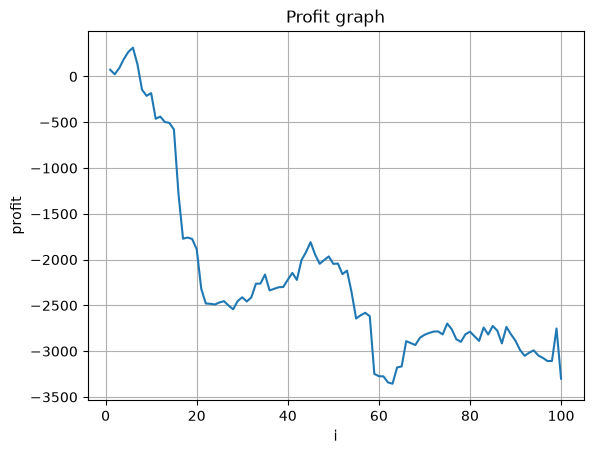

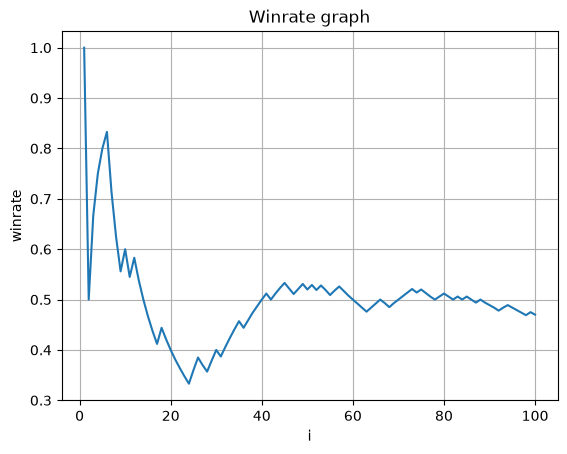

In [23]:
from dataWorker import *
from datetime import datetime
from dataWorker import getOHLC
import matplotlib.pyplot as plt
# loading real data for test

profit_ttl = 0
wins = 0
profit_history = []
winrate_history = []
iters = 100
for i, interval in enumerate(intervals[:iters]):
    start = interval[0]
    end = interval[1]
    test_df = getOHLC('BTCUSDT', start, end, normalize=True)
    test_df = prepare_features_and_labels(test_df, horizon=5, flat_threshold=0.001) 
    #print(f"Selected interval from {datetime.fromtimestamp(start//1000)} to {datetime.fromtimestamp(end//1000)}")
    result = predict(model, test_df, feature_cols, window=5)
    #print(result)
    
    # collecting data from exchange
    df_plot = getOHLC('BTCUSDT', start, end)
    df_plot = df_plot.set_index("timestamp")
    df_final = getOHLC('BTCUSDT', (end//1000+60)*1000,(end//1000+60*5)*1000)
    df_final = df_final.set_index("timestamp")

    # calculate price change
    open_price = float(df_final.iloc[0]['open'])
    close_price = float(df_final.iloc[4]['close'])
    price_change = round(close_price - open_price, 3)
    
    if result.get('prediction') == 'down':
        profit = price_change * -1
    if result.get('prediction') == 'up':
        profit = price_change
        
    if profit>0: wins += 1
    profit_ttl += profit
    profit_ttl = round(profit_ttl, 2)
    print(f"win {profit>0}, profit {profit} points, ttl {profit_ttl}, winrate {round(wins/(i+1),3)}")
    
    profit_history.append(profit_ttl)
    winrate_history.append(round(wins/(i+1),3))
    

    # plotting
    # fig, ax = mpf.plot(df_plot, type='candle',returnfig=True, figsize = (10,5))
    # ax[0].set_title('Input Data')
    # fig,ax = mpf.plot(df_final, type='candle',returnfig=True, figsize = (10,5))
    # ax[0].set_title('Prediction Window')
    
print(f"Profit: {profit_ttl} points with winrate {round(wins/iters,2)}")    

fig, ax = plt.subplots()
t = np.arange(1,iters+1, 1)
ax.plot(t, profit_history)
ax.set(xlabel='i', ylabel='profit',
       title='Profit graph')
ax.grid()
plt.show()

fig, ax = plt.subplots()
ax.plot(t, winrate_history)
ax.set(xlabel='i', ylabel='winrate',
       title='Winrate graph')
ax.grid()
plt.show()

In [24]:
# from dataWorker import getOHLC
# import mplfinance as mpf

# df_plot = getOHLC('BTCUSDT', start, end)
# df_plot = df_plot.set_index("timestamp")
# df_final = getOHLC('BTCUSDT', (end//1000+60)*1000,(end//1000+60*5)*1000)
# df_final = df_final.set_index("timestamp")

# open_price = float(df_final.iloc[0]['open'])
# close_price = float(df_final.iloc[4]['close'])

# profit = round(close_price - open_price, 3)
# if result.get('prediction') == 'down':
#     if profit < 0: print(f'win {abs(profit)} points')
#     else: print(f'loss {abs(profit)} points')
# if result.get('prediction') == 'up':
#     if profit > 0: print(f'win {abs(profit)} points')
#     else: print(f'loss {abs(profit)} points')

# # plotting
# fig, ax = mpf.plot(df_plot, type='candle', returnfig=True, figsize = (10,5))
# ax[0].set_title('Input Data')
# fig,ax = mpf.plot(df_final, type='candle', returnfig=True, figsize = (10,5))
# ax[0].set_title('Prediction Window')